# Klustring

Klustring är en oövervakad ML-teknik som går ut på att träna en modell i att hitta grupper av observationer som ligger nära varandra. Det är alltså ett slags klassificering fast utan det "facit" vi har när vi sysslar med klassificering.

## K-means
Den vanligaste modellen att använda vid klustring kallas *K-means*. 

*K* står för antalet kluster, och *means* för att den använder sig av medelavstånd för att avgöra vilket kluster en viss observation tillhör.

## Andra klustringsmetoder
Det finns ett gäng andra metoder man kan använda för klustring. En överblick över dem och vilken situation de passar till finns [här](https://scikit-learn.org/stable/modules/clustering.html#overview-of-clustering-methods).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns; sns.set_theme(font_scale=.75, style="dark")
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from sklearn.metrics import silhouette_score, silhouette_samples, classification_report


## Skapa dataset

In [4]:
X, y = make_blobs(n_samples=1000, centers=5, cluster_std=[1.2, 1.2, 1.8, 1.4, 1.2], random_state=43)

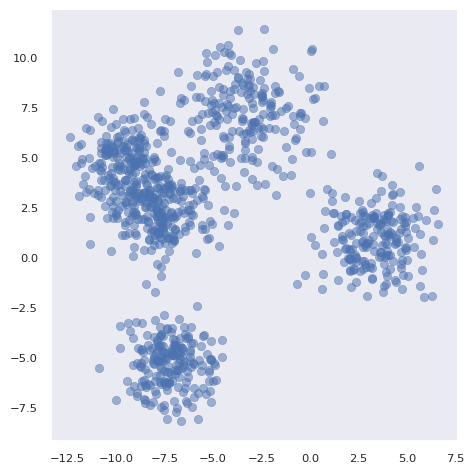

In [5]:
sns.relplot(x=X[:, 0], y=X[:, 1], alpha=.5, edgecolor=None)

In [12]:
km = KMeans(n_clusters=5, random_state=42)

labels = km.fit_predict(X)

In [14]:
km.n_iter_

9

[[], []]

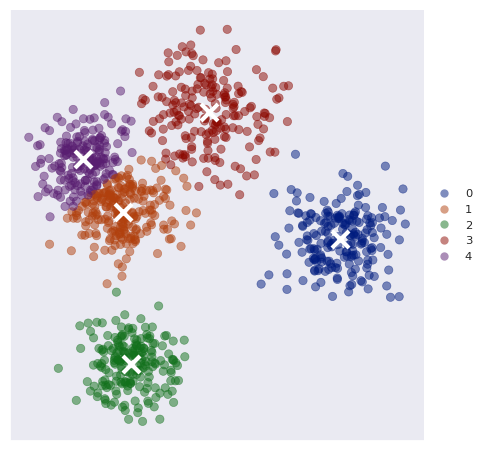

In [15]:
g = sns.relplot(x=X[:, 0], y=X[:, 1], hue=labels, alpha=.5, palette="dark", edgecolor=None)
g.ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c="w", marker="x", s=150, lw=3)
g.ax.set(xticks=(), yticks=())

### Övning
* Skapa ett dataset med `make_blobs()`. Testa gärna andra kombinationer än de jag har använt. Fler eller färre `centers`, annan spridning med `cluster_std`, etc.
* Träna en `KMeans`-modell på `X` och skapa *labels*. Man kan använda `fit_predict()`-metoden för att göra båda stegen samtidigt.
* Visualisera resultaten:
    * En *scatter plot* med originaldatan, färgad efter *labels*
    * En *scatter plot* på samma `Axes` med centroiderna.

[[], []]

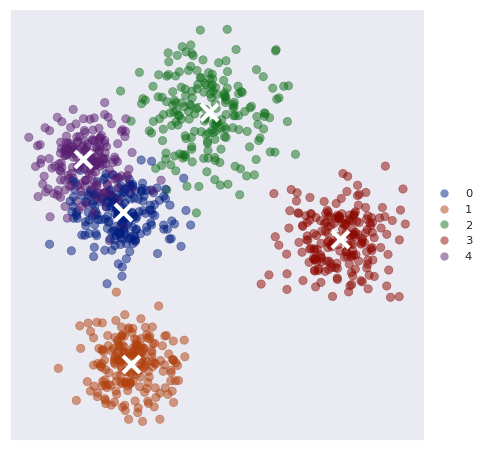

In [16]:
g = sns.relplot(x=X[:, 0], y=X[:, 1], hue=y, alpha=.5, palette="dark", edgecolor=None)
g.ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c="w", marker="x", s=150, lw=3)
g.ax.set(xticks=(), yticks=())

## Visualisera beslutsgränser

In [9]:
def display_cluster_boundaries(model: KMeans, X: np.ndarray, h=.02, color_data=False, target=None, i=None, save=False):
    boundary_alpha = 1
    if color_data:
        if target is None:
            raise ValueError("target parameter must be set with color_data=True")
        boundary_alpha = .5

    # Plot the decision boundary. For that, we will assign a color to each
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Obtain labels for each point in mesh. Use last trained model.
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(
        Z,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        cmap="tab10",
        aspect="auto",
        origin="lower",
        alpha=boundary_alpha
    )

    if not color_data:
        ax.scatter(X[:, 0], X[:, 1], c="k", s=2)
    else:    
        ax.scatter(X[:, 0], X[:, 1], c=target, cmap="tab10", s=10)
    # Plot the centroids as a white X
    centroids = model.cluster_centers_
    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=169,
        linewidths=3,
        color="w",
        zorder=10,
    )
    if i is not None:
        # plt.text(x_max-(x_max-x_min/10), y_max-(y_max-y_min/10), str(i))
        plt.text(x_max-1, y_max-1, str(i))
    ax.set(title=
        "K-means clustering\n"
        "Centroids are marked with white cross",
        xlim=(x_min, x_max),
        ylim=(y_min, y_max),
        xticks=(()),
        yticks=(()),
    )
    if save:
        fig.savefig(f"images/anim/clustering_{i:0>2}.png")
        plt.close()
    else:
        plt.show()

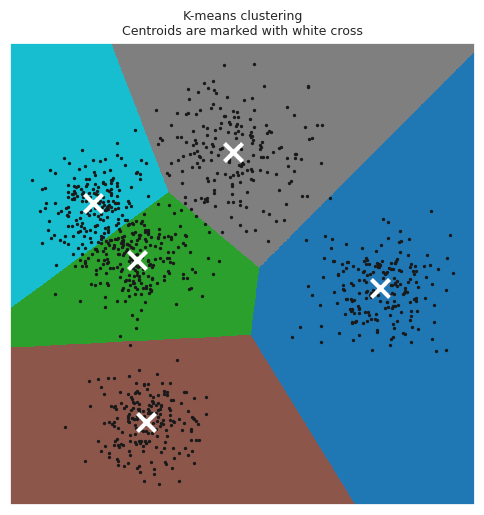

In [17]:
display_cluster_boundaries(km, X)

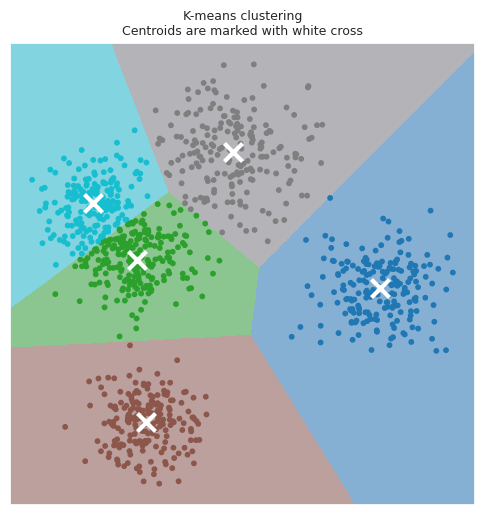

In [18]:
display_cluster_boundaries(km, X, color_data=True, target=labels)

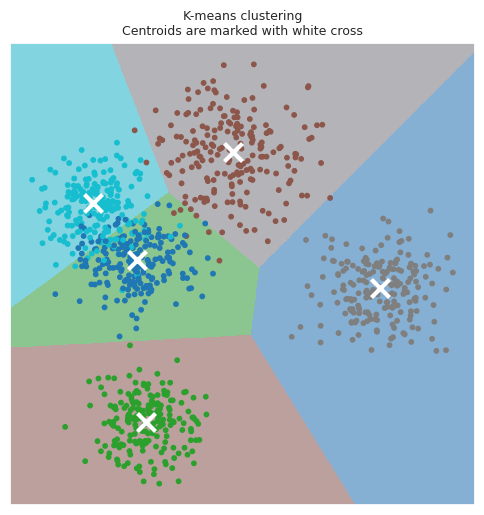

In [19]:
display_cluster_boundaries(km, X, color_data=True, target=y)

In [20]:
silhouette_score(X, labels)

0.5668044158565327

## Analys av 80-talshits med PCA och *K-Means*-klustring

Vi kan använda PCA och *K-Means*-klustring för att analysera ett dataset med låtar från 1980-talet.

Resultaten skulle till exempel kunna ligga till grund för ett rekommendationssystem.

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [22]:
hits = pd.read_csv("1980sClassics.csv", index_col=False)

### Kort EDA

Datan är från Spotify. 998 låtar från 1980-talet, med kolumner som beskriver olika aspekter av låten.

In [23]:
hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    object 
 1   Artist            998 non-null    object 
 2   Duration          998 non-null    object 
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    int64  
dt

In [24]:
hits.head()

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


Vi plockar ut ett antal kolumner vi är intresserade av.

In [55]:
X = hits[["Danceability", "Energy", "Loudness", "Acousticness", "Instrumentalness", "Valence", "Tempo"]]

Eftersom vi ska göra PCA på datan standardiserar vi värdena. De flesta är redan i en bra form, det är framförallt `Tempo`-kolumnen som ställer till det. Men det är ofta en bra idé att köra datan genom en `StandardScaler`!

In [56]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Vi gör en PCA med två komponenter. Poängen här är analys så det är bra med få dimensioner så vi har något att visualisera.

In [57]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca.explained_variance_ratio_

array([0.35954471, 0.19826874])

Vår två komponenter står för över 50% av variansen så det är helt ok!

Nu kommer vi arbeta med vår dimensionsreducerade data ett litet tag och sedan återföra våra *labels* till originaldatan.

### Antal kluster

Vi har egentligen ingen aning som hur många kluster vi ska ha för vi har inget facit. Då kan vi använda *silhouette score*. 

#### *Silhouette score*

*Silhouette score* beskriver hur bra observationerna i ett kluster passar till det klustret jämfört med det kluster som är närmast.

$ score = \dfrac{b-a}{max(a, b)}$

där $a$ = medelavståndet till alla andra punkter i klustret observationen tillhör,

och $b$ = medelavståndet till alla punkter i det närmste klustret som observationen inte tillhör.

Vi räknar enklast ut *silhouette score* med funktionen `silhouette_score` från `metrics`-modulen.

#### Välja antal kluster
Antingen kollar vi *silhouette score* som en funktion av antalet kluster.

In [58]:
n_clusters = np.arange(2, 9)
scores = [silhouette_score(X, KMeans(n_clusters=n, random_state=42).fit_predict(X_pca)) for n in n_clusters]

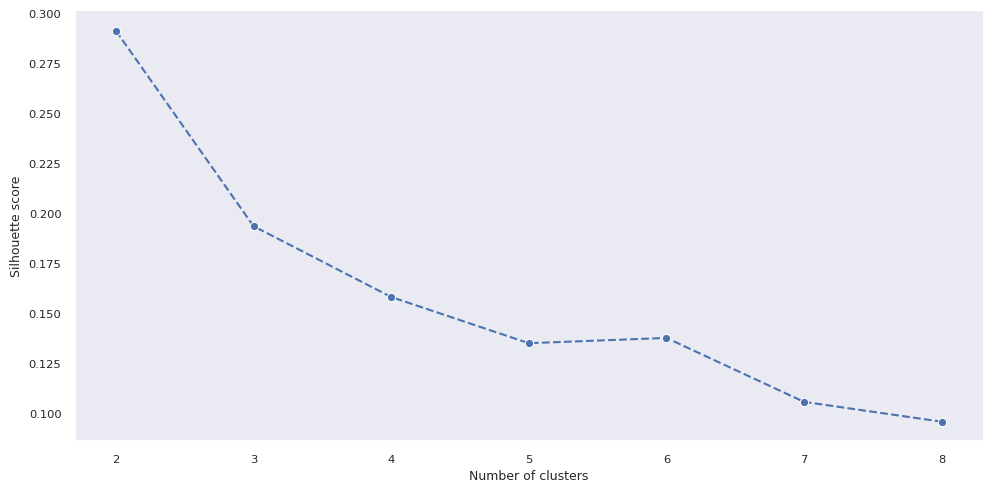

In [59]:
g = sns.relplot(x=n_clusters, y=scores, kind="line", marker="o", linestyle="--", aspect=2)
g.ax.set(xlabel="Number of clusters", ylabel="Silhouette score");

Fyra kluster verkar vara en bra idé. Två ger bäst *score* men vi vill ha lite fler kluster att arbeta med.

### Visualisering av *silhouette coefficient*

Vill vi ha ännu bättre koll kan vi visualisera siluett-koefficienterna. Det är ett sätt att titta på hur avstånden är fördelade inom varje kluster.

Kodexemplet är plockat från *scikit-learn*-dokumentationen [här](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#).

In [60]:

def display_silhouette_coefs(X, n_clusters=8, range_=False, min_n=2, max_n=8, step=1):
    if range_:
        range_n_clusters = np.arange(min_n, max_n, step)
    else:
        range_n_clusters = [n_clusters]

    for n_clusters in range_n_clusters:
        _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.set(
            title="Silhouette scores",
            xlim=(0, 1), 
            ylim=(0, len(X) + n_clusters + 1 * 10), 
            xticks=np.linspace(0, 1, 5), 
            yticks=())

        km = KMeans(n_clusters=n_clusters, random_state=42)
        labels = km.fit_predict(X)

        silhouette_avg = silhouette_score(X, labels)

        sample_silhouette_values = silhouette_samples(X, labels)
        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = plt.get_cmap("nipy_spectral")(i/n_clusters)

            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=.7
            )

            ax1.text(-.05, y_lower+ .5*size_cluster_i, str(i))

            y_lower = y_upper + 10
        
        ax1.axvline(x=silhouette_avg, color="r", linestyle="--")

        colors = plt.get_cmap("nipy_spectral")(labels / n_clusters)
        ax2.scatter(
            X[:, 0], X[:, 1], marker=".", c=colors, s=30, lw=0, alpha=.7
        )

        centers = km.cluster_centers_

        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="w",
            s=200,
            edgecolor="k"
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker=f"${i}$", s=50, edgecolor="k")
        
        ax2.set(title="Clustered data")

    plt.show()


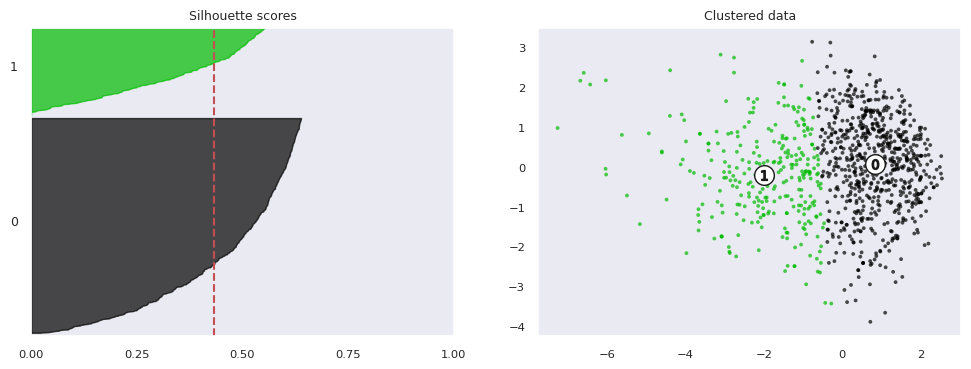

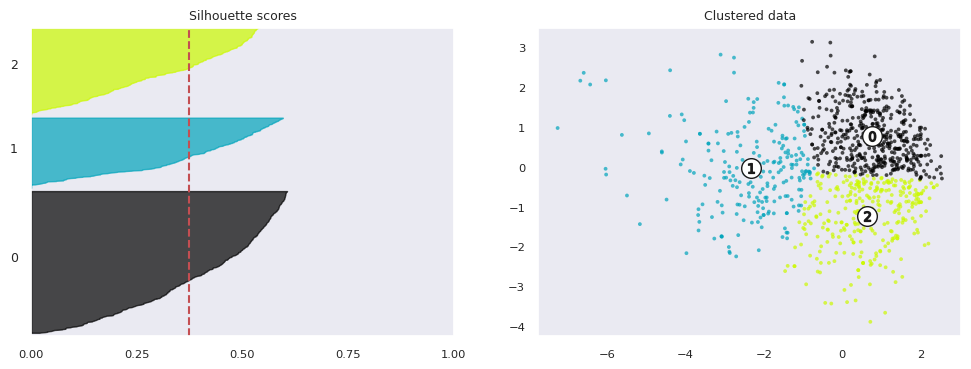

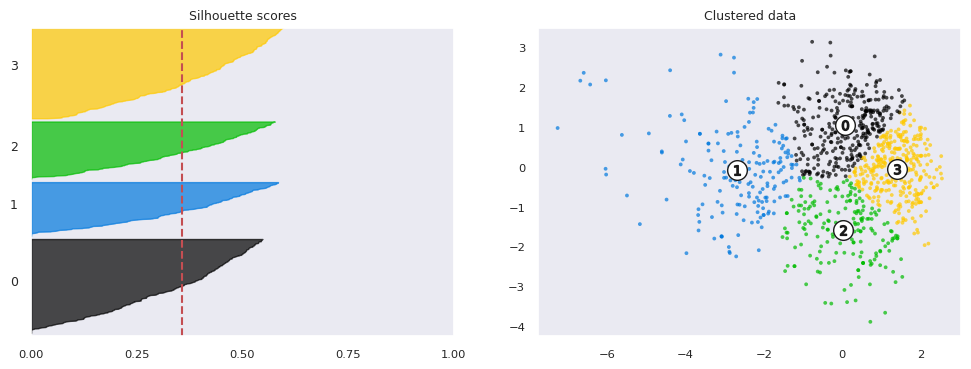

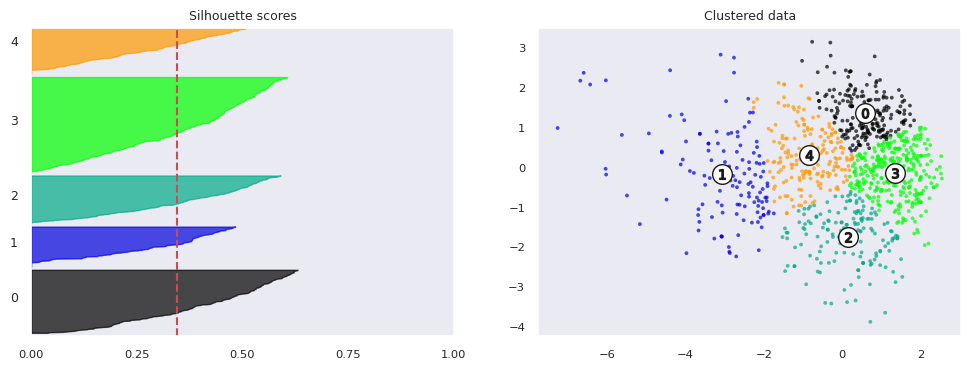

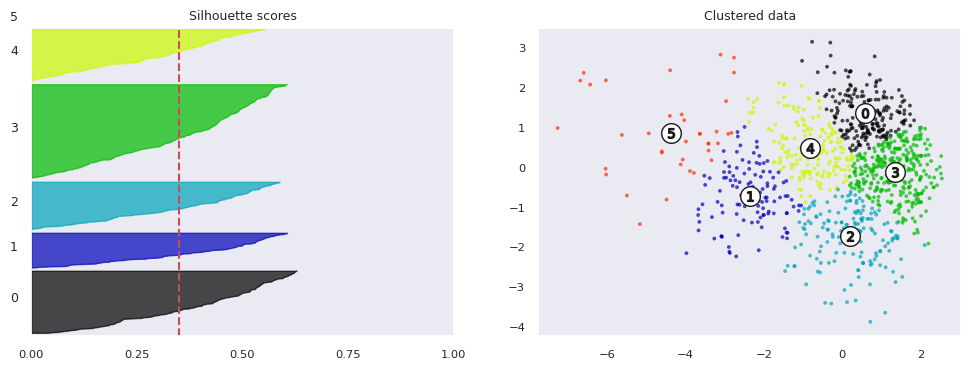

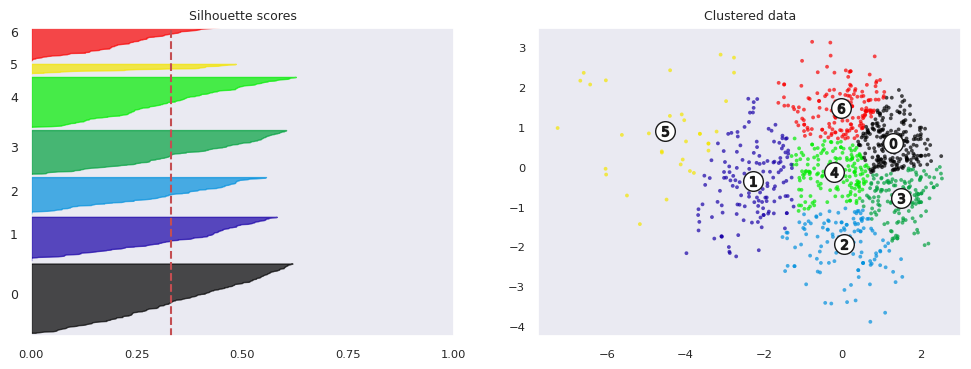

In [61]:
display_silhouette_coefs(X_pca, range_=True)

Det talar fortfarande för att fyra kluster verkar lagom.

Vi gör en ny `KMeans`-modell med fyra kluster, tränar den och skapar våra *labels*.

In [34]:
km = KMeans(n_clusters=4)

labels = km.fit_predict(X_pca)

Vi kör en snabb koll på våra dimensionsreducerade data med *labels*.

<Axes: >

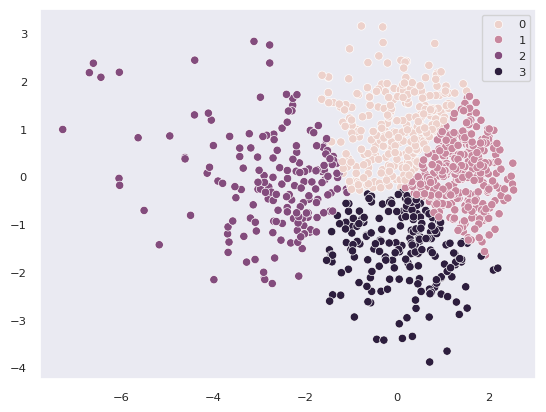

In [35]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels)

Nu kan vi återföra vårt dataset till originaldimensionaliteten.

In [36]:
X_inv = pca.inverse_transform(X_pca)

Vi skapar en `DataFrame` och lägger till våra *labels* som en kolumn.

In [37]:
df = pd.DataFrame(X_inv, columns=scaler.feature_names_in_)

df["label"] = labels

Nu kan vi göra en *pairplot*, som visar hur de olika kolumnerna förhåller sig till varandra. Med våra *labels* kan vi se om våra kluster verkar beskriva observationer som har något gemensamt.

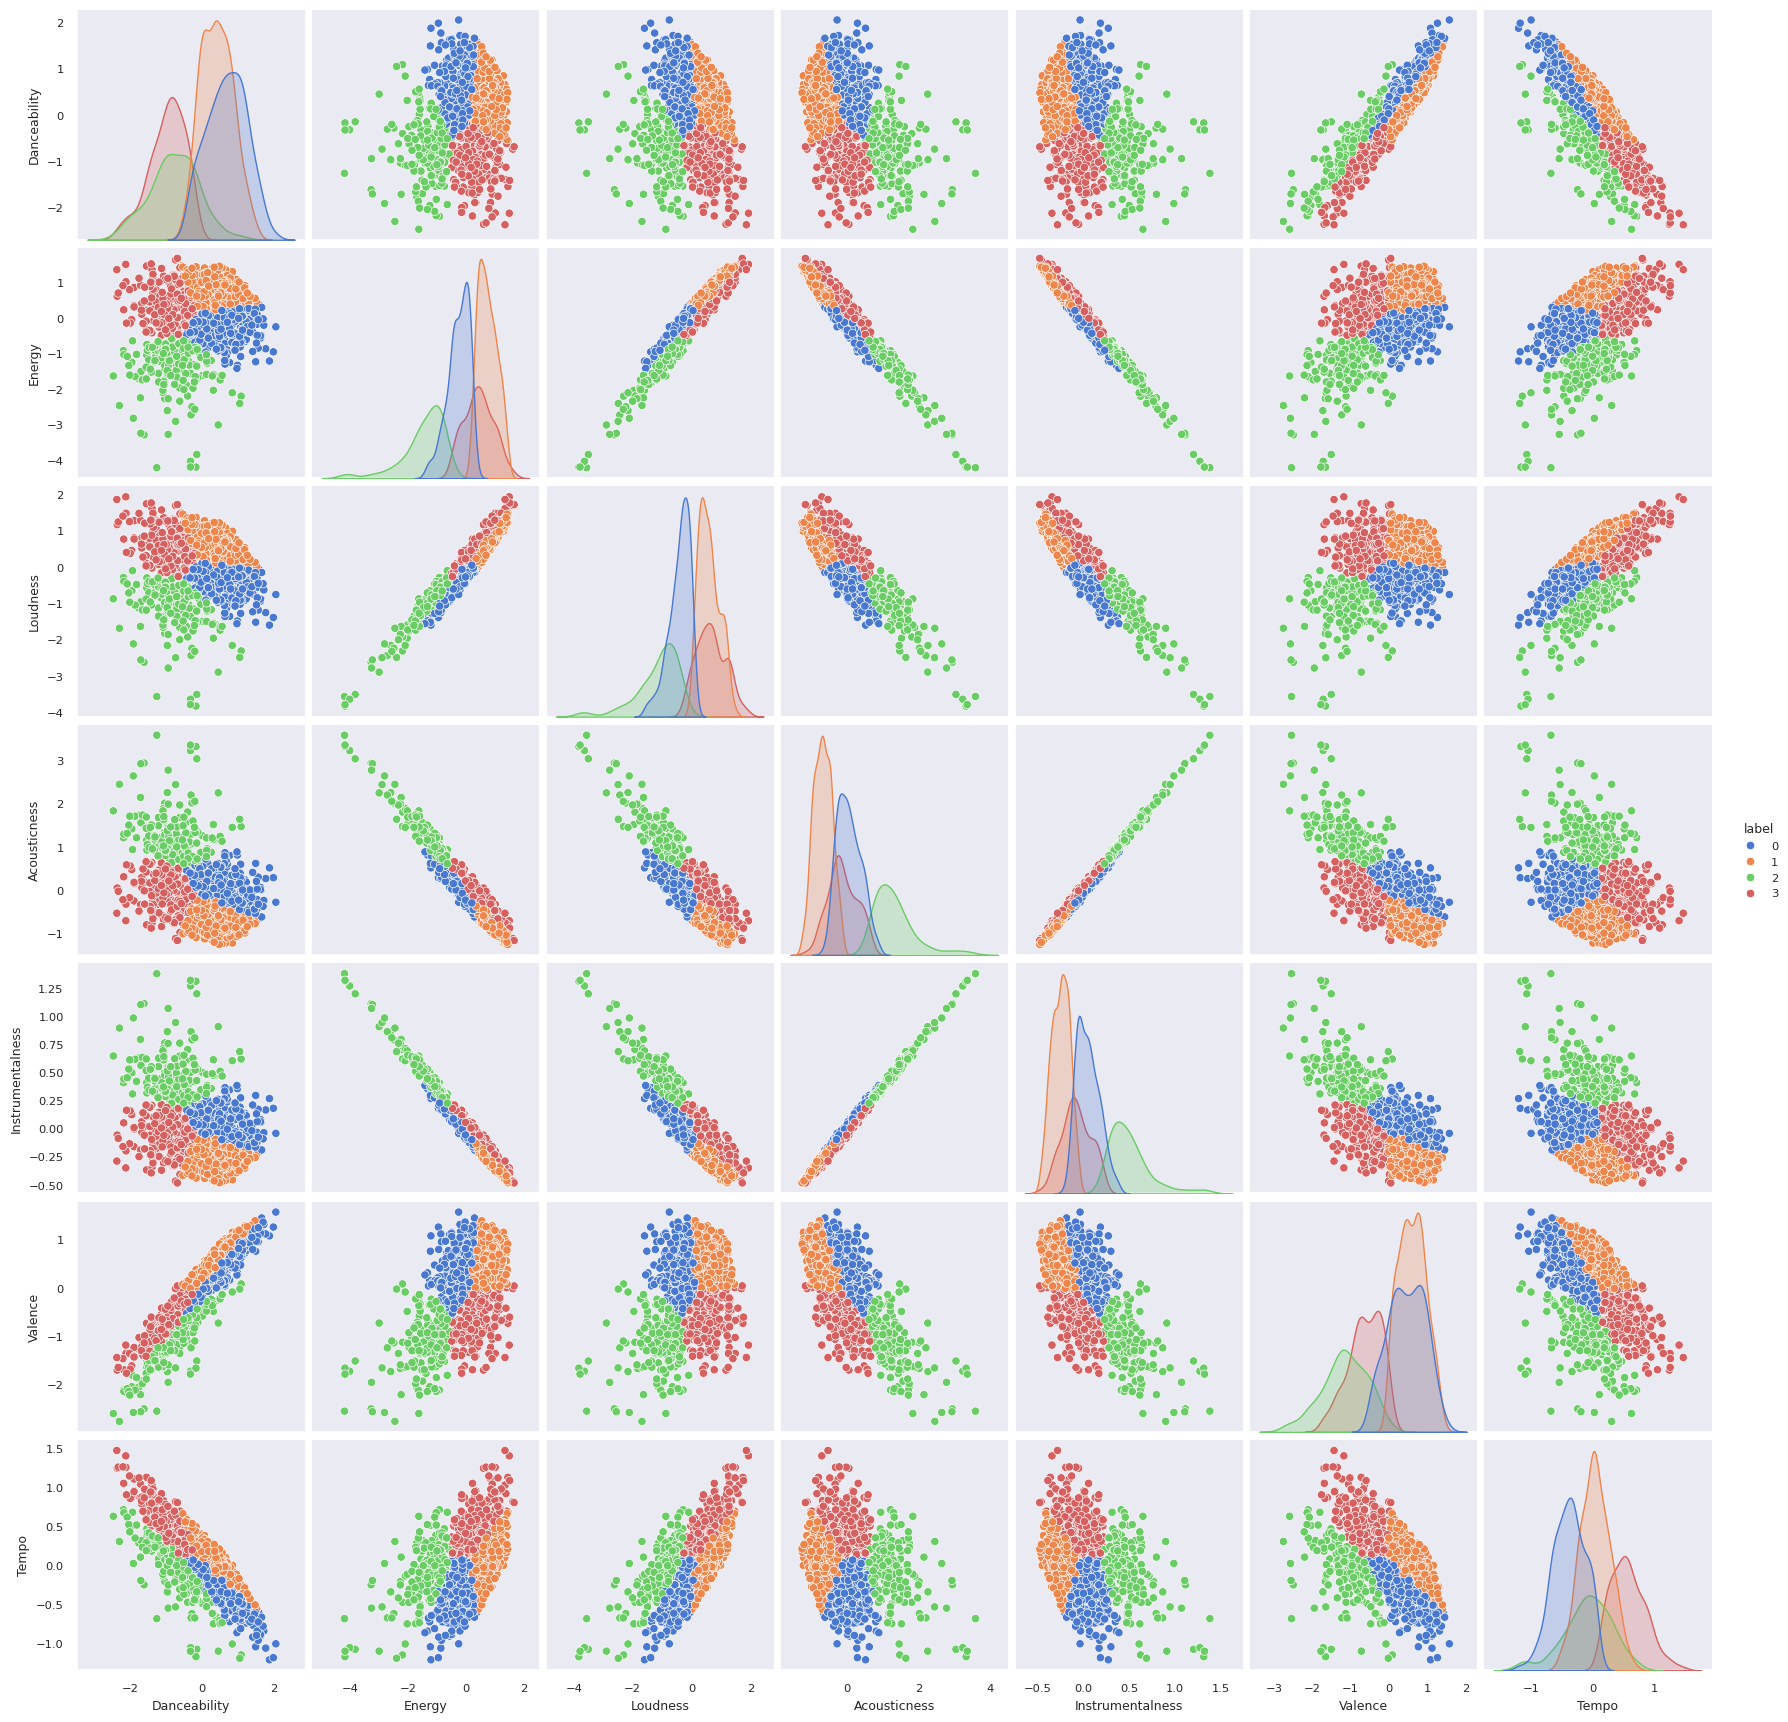

In [38]:
sns.pairplot(df, hue="label", palette="muted")

Nu kan vi lägga till våra *labels* till originaldatan och fortsätta vår analys.

In [39]:
hits["label"] = labels

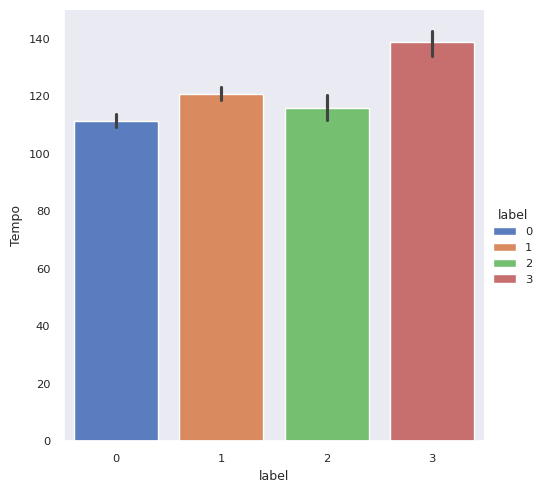

In [40]:
sns.catplot(hits, x="label", y="Tempo", kind="bar", hue="label", palette="muted")

In [41]:
hits[hits.label == 0]

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year,label
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.6210,0.000000,0.1790,0.352,100.017,80,1980,0
7,Rock With You,Michael Jackson,3:40,4,0.808,0.535,1,-12.521,1,0.0353,0.1790,0.000099,0.1580,0.848,114.031,79,1980,0
9,Upside Down,Diana Ross,3:29,4,0.792,0.647,4,-8.314,1,0.0450,0.2550,0.000223,0.1320,0.694,102.477,77,1980,0
10,Escape (THE Piña Colada Song),Rupert Holmes,4:36,4,0.835,0.509,0,-13.668,1,0.0548,0.4690,0.000004,0.0436,0.949,138.711,76,1980,0
16,Another One Bites The Dust,Queen,3:34,4,0.932,0.528,5,-6.472,0,0.1610,0.1150,0.329000,0.1630,0.757,109.975,74,1980,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,What You Don’t Know,Exposé,2:45,4,0.901,0.489,2,-8.766,1,0.3830,0.4310,0.000000,0.7200,0.603,127.969,48,1989,0
985,Surrender To Me,Ann Wilson and Robin Zander,3:34,4,0.624,0.672,0,-11.108,1,0.0321,0.0191,0.511000,0.0600,0.925,108.746,45,1989,0
988,Secret Rendezvous,Karyn White,5:37,4,0.733,0.689,10,-13.001,0,0.0388,0.0503,0.001150,0.0656,0.888,111.695,37,1989,0
989,Girl I’m Gonna Miss You,Milli Vanilli,4:24,4,0.732,0.566,9,-7.760,1,0.0505,0.1310,0.000042,0.1840,0.763,75.692,36,1989,0


In [42]:
hits[hits.label == 1]

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year,label
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980,1
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980,1
13,It’s Still Rock And Roll To Me,Billy Joel,2:56,4,0.752,0.684,0,-7.599,1,0.1500,0.09940,0.000000,0.0897,0.539,141.075,75,1980,1
14,On The Radio,Donna Summer,3:50,4,0.758,0.686,11,-6.346,1,0.0792,0.08480,0.001330,0.1420,0.444,130.008,75,1980,1
15,Still,Commodores,4:06,4,0.946,0.646,5,-6.604,1,0.2100,0.21900,0.000000,0.0643,0.961,127.978,75,1980,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983,Forever Your Girl,Paula Abdul,5:00,4,0.702,0.891,2,-7.873,1,0.0446,0.18500,0.045300,0.0712,0.748,119.963,46,1989,1
984,It’s No Crime,Babyface,4:51,4,0.687,0.800,0,-7.682,1,0.0327,0.07500,0.371000,0.1200,0.945,147.026,45,1989,1
986,I Wanna Have Some Fun,Samantha Fox,2:44,4,0.640,0.880,2,-4.285,0,0.0401,0.16500,0.000021,0.0512,0.962,130.209,42,1989,1
992,The Lover In Me,Sheena Easton,5:01,4,0.818,0.808,7,-8.536,0,0.0467,0.02740,0.000000,0.0592,0.931,115.221,28,1989,1


In [43]:
hits[hits.label == 2]

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year,label
12,Lady,Kenny Rogers,3:03,4,0.539,0.1600,3,-13.285,1,0.0329,0.881,0.000268,0.1050,0.322,81.446,76,1980,2
19,All Out Of Love,Air Supply,4:03,4,0.513,0.2620,0,-16.875,1,0.0276,0.313,0.000006,0.4560,0.357,108.383,73,1980,2
25,More Love,Kim Carnes,2:21,4,0.482,0.0191,4,-28.939,1,0.0348,0.975,0.000056,0.1140,0.333,99.151,67,1980,2
27,Woman In Love,Barbra Streisand,3:51,4,0.469,0.2780,3,-16.311,0,0.0280,0.248,0.000126,0.1330,0.331,169.735,67,1980,2
29,Sailing,Christopher Cross,4:18,4,0.480,0.1910,9,-20.594,1,0.0341,0.643,0.000144,0.2630,0.187,149.125,66,1980,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,Eternal Flame,The Bangles,3:55,3,0.521,0.2330,7,-13.683,1,0.0254,0.635,0.000000,0.2450,0.400,78.930,55,1989,2
961,The Living Years,Mike + The Mechanics,5:30,4,0.518,0.4170,8,-13.268,1,0.0325,0.580,0.000000,0.0722,0.311,97.630,54,1989,2
964,Giving You The Best That I Got,Anita Baker,3:53,4,0.637,0.5420,9,-8.173,1,0.0357,0.765,0.000000,0.3020,0.380,105.324,53,1989,2
968,Shower Me With Your Love,Surface,4:54,4,0.632,0.3560,9,-10.811,1,0.0309,0.523,0.000006,0.0961,0.197,131.280,52,1989,2


In [44]:
hits[hits.label == 3]

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year,label
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.039300,0.000002,0.1510,0.190,84.828,92,1980,3
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.039000,0.000000,0.1070,0.259,149.907,82,1980,3
5,Desire,Andy Gibb,2:59,4,0.587,0.924,11,-5.433,0,0.0457,0.031100,0.017100,0.2300,0.509,140.009,79,1980,3
6,Real Love,Doobie Brothers,3:09,4,0.417,0.686,7,-6.484,1,0.0373,0.095500,0.028700,0.0989,0.625,204.113,79,1980,3
8,Sara,Fleetwood Mac,3:34,4,0.576,0.683,7,-5.103,1,0.1180,0.410000,0.000000,0.0819,0.433,151.566,77,1980,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,My Heart Can’t Tell You No,Rod Stewart,4:33,4,0.557,0.652,6,-5.400,0,0.0250,0.175000,0.000000,0.2560,0.465,89.992,37,1989,3
990,Two Hearts,Phil Collins,3:14,4,0.200,0.964,0,-3.691,1,0.1160,0.000504,0.000002,0.9360,0.231,147.324,31,1989,3
991,I’ll Be There For You,Bon Jovi,4:23,4,0.516,0.539,11,-6.453,0,0.0896,0.234000,0.000092,0.1140,0.311,123.936,30,1989,3
993,When I Looked At Him,Exposé,4:19,4,0.455,0.713,8,-10.959,1,0.0423,0.230000,0.000332,0.3700,0.469,169.633,24,1989,3
